# Fase 2: Feature Engineering — Ventanas Deslizantes

Construcción del dataset de modelización a partir de las transacciones limpias de Fase 1.

**Esquema temporal.** Para cada fecha de observación *t* (mensual):

| Bloque | Ventana | Uso |
|---|---|---|
| Features | `[t - 6 meses, t)` | Pasado observable — RFM + comportamiento |
| Target | `[t, t + 90 días)` | Futuro — se predice, nunca se observa |

Los dos bloques son **disjuntos**: ninguna variable de entrada contiene información del período que se predice.

**Población.** Clientes con al menos una **línea de compra** (`Quantity > 0`) en la ventana
histórica. Un cliente cuya única actividad fue devolver no ha comprado, y por tanto no forma
parte de la base sobre la que se decide una acción de retención.

**Dos targets complementarios por construcción, mismo horizonte de 90 días:**
- `churn` — el cliente no realiza ninguna **compra** en la ventana futura.
- `future_monetary_90d` — gasto del cliente en la ventana futura (£0 si no vuelve).

Ambos se definen sobre compras, de modo que `churn == 1 ⟺ future_monetary_90d == 0`. Esa
equivalencia es la que permite descomponer el valor esperado en Fase 3b sin sesgo:
`valor_esperado = (1 − P(churn)) × E[gasto | vuelve]`.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import inspect

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))  # tfm_pipeline.py vive en src/, no junto al notebook
import tfm_pipeline as tfm

tfm.setup_notebook()

# Los parámetros del esquema temporal y el contrato de features viven en
# tfm_pipeline.py: ningún notebook los redeclara.
LOOKBACK_MONTHS = tfm.LOOKBACK_MONTHS
HORIZON_DAYS = tfm.HORIZON_DAYS
FEATURES = tfm.FEATURES
DESCRIPTIVAS = tfm.DESCRIPTIVAS
KEYS, TARGETS = tfm.KEYS, tfm.TARGETS

print(f"Histórico {LOOKBACK_MONTHS} meses · horizonte {HORIZON_DAYS} días")
print(f"Features de modelización ({len(FEATURES)}): {', '.join(FEATURES)}")
print(f"Descriptivas (excluidas del modelo): {', '.join(DESCRIPTIVAS)}")

Histórico 6 meses · horizonte 90 días
Features de modelización (7): recency_days, frequency, monetary, return_rate, customer_age_days, avg_items_per_transaction, unique_products
Descriptivas (excluidas del modelo): avg_order_value


In [2]:
df = pd.read_csv('../data/processed/online_retail_II_cleaned.csv', parse_dates=['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)

observation_dates = pd.read_csv('../data/processed/observation_dates.csv', parse_dates=['observation_date'])['observation_date']

print(f"Transacciones: {len(df):,} | Clientes: {df['Customer ID'].nunique():,}")
print(f"Rango: {df['InvoiceDate'].min().date()} a {df['InvoiceDate'].max().date()}")
print(f"Ventanas de observación: {len(observation_dates)} "
      f"({observation_dates.min().date()} a {observation_dates.max().date()})")

Transacciones: 824,355 | Clientes: 5,940
Rango: 2009-12-01 a 2011-12-09
Ventanas de observación: 16 (2010-06-01 a 2011-09-01)


## Construcción de una ventana

`tfm.build_window()` genera, para una fecha de observación, una fila por cliente activo con sus
features (pasado) y sus dos targets (futuro).

Vive en `tfm_pipeline.py` y no en el notebook por un motivo concreto: el prototipo de
productivización de la Fase 5 llama al **mismo núcleo de cálculo** (`_aggregate_features`) para
scorear un cliente suelto. Si la definición de una feature cambiara aquí y no allí, el modelo
recibiría en producción variables distintas de las que vio entrenando — el fallo silencioso más
caro de un pipeline de ML. Compartir el código lo hace imposible por construcción.

In [3]:
# El código completo está en tfm_pipeline.py; se muestra aquí por transparencia.
print(inspect.getsource(tfm._aggregate_features))
print(inspect.getsource(tfm.build_window))

def _aggregate_features(past: pd.DataFrame, observation_date: pd.Timestamp) -> pd.DataFrame:
    """Núcleo de cálculo de features. Recibe las transacciones de [t-lookback, t).

    Población: clientes con al menos una LÍNEA DE COMPRA (Quantity > 0) en la
    ventana. Un cliente cuya única actividad fue devolver no ha comprado, y por
    tanto no forma parte de la base sobre la que se predice retención.

    Separación de señales:
      - `frequency`, `monetary`, `unique_products` y `total_quantity` se calculan
        SOLO sobre líneas de compra. Las facturas de cancelación (`Invoice`
        empieza por C) no cuentan como compras.
      - Las devoluciones se capturan aparte, en `return_rate`, sobre el total de
        facturas del cliente en la ventana.
    """
    compras = past[past['Quantity'] > 0]
    if compras.empty:
        return pd.DataFrame()

    g = compras.groupby('Customer ID')
    w = pd.DataFrame({
        'first_purchase': g['InvoiceDate'].min(),
        'last_purchas

## Acumular las ventanas

In [4]:
feature_set = pd.concat(
    [tfm.build_window(df, obs) for obs in observation_dates],
    ignore_index=True
)

print(f"Observaciones cliente-ventana: {len(feature_set):,}")
print(f"Clientes únicos: {feature_set['CustomerID'].nunique():,}")
print(f"Churn rate global: {feature_set['churn'].mean():.1%}")

# Puente entre las dos poblaciones del trabajo: el dataset limpio y la base analizada.
# Son cifras distintas y se confunden con facilidad, así que la relación sale de aquí.
n_panel, n_limpio = feature_set['CustomerID'].nunique(), df['Customer ID'].nunique()
print(f"Cobertura: {n_panel:,} de {n_limpio:,} clientes del dataset limpio "
      f"({n_panel / n_limpio:.0%}) entran en al menos una ventana de observación; "
      f"los {n_limpio - n_panel:,} restantes compraron sólo fuera del calendario.")

Observaciones cliente-ventana: 48,394
Clientes únicos: 5,249
Churn rate global: 51.1%
Cobertura: 5,249 de 5,940 clientes del dataset limpio (88%) entran en al menos una ventana de observación; los 691 restantes compraron sólo fuera del calendario.


## Validación

Diez comprobaciones que hacen fallar el notebook si el esquema temporal o la definición de
población se rompen: cinco acotan las variables a su rango teórico, dos protegen contra las
fugas de información que se detectaron y corrigieron durante el trabajo, dos verifican que
los targets son complementarios y una que no hay clientes duplicados dentro de una ventana.

La prueba de fuga **no** comprueba igualdad exacta —una fuga que acertara el 99% de las filas
pasaría—, sino que mide el grado de acuerdo y el AUC de `recency_days` como predictor único: si
el target volviera a mirar al pasado, ambos se dispararían a 1.

In [5]:
from sklearn.metrics import roc_auc_score

# Cota teórica de la ventana histórica, derivada del calendario (no un número mágico).
max_lookback = max((obs - (obs - pd.DateOffset(months=LOOKBACK_MONTHS))).days
                   for obs in observation_dates)

# 1-2. Rangos teóricos de las variables.
assert (feature_set['monetary'] >= 0).all(), "monetary negativo"
assert (feature_set['frequency'] >= 1).all(), "cliente sin ninguna factura de compra"
assert feature_set['recency_days'].between(0, max_lookback).all(), \
    f"recency fuera de la ventana histórica (0-{max_lookback})"
assert feature_set['customer_age_days'].between(0, max_lookback).all(), \
    "customer_age fuera de la ventana histórica"
assert feature_set['return_rate'].between(0, 1).all(), "return_rate fuera de [0, 1]"

# 3. El target no puede ser una función (ni siquiera aproximada) del pasado.
acuerdo = (feature_set['churn'] == (feature_set['recency_days'] >= 90).astype(int)).mean()
auc_recency = roc_auc_score(feature_set['churn'], feature_set['recency_days'])
assert acuerdo < 0.95, f"churn casi determinista desde recency (acuerdo {acuerdo:.1%})"
assert auc_recency < 0.90, f"recency sola separa el target casi perfectamente (AUC {auc_recency:.3f})"

# 4. Los dos targets son complementarios EN AMBAS DIRECCIONES.
assert (feature_set.loc[feature_set['churn'] == 1, 'future_monetary_90d'] == 0).all(), \
    "un cliente marcado churn tiene gasto futuro"
assert (feature_set.loc[feature_set['churn'] == 0, 'future_monetary_90d'] > 0).all(), \
    "un cliente no-churn no tiene gasto futuro: los targets no son complementarios"

# 5. Una fila por cliente y ventana.
assert not feature_set.duplicated(['CustomerID', 'observation_date']).any(), \
    "cliente duplicado dentro de una misma ventana"

print("Validaciones OK")
print(f"  Acuerdo churn vs (recency >= 90) : {acuerdo:.1%}   (fuga si > 95%)")
print(f"  ROC-AUC de recency_days sola     : {auc_recency:.3f}  (fuga si > 0,90)")
print(f"  Cota de la ventana histórica     : {max_lookback} días")
print("\nChurn rate por ventana:")
print(feature_set.groupby('window_month_year')['churn'].agg(['size', 'mean']).round(3).to_string())

Validaciones OK
  Acuerdo churn vs (recency >= 90) : 60.0%   (fuga si > 95%)
  ROC-AUC de recency_days sola     : 0.659  (fuga si > 0,90)
  Cota de la ventana histórica     : 184 días

Churn rate por ventana:
                   size   mean
window_month_year             
2010-06            2703  0.505
2010-07            2757  0.493
2010-08            2832  0.431
2010-09            2868  0.384
2010-10            2924  0.423
2010-11            3222  0.509
2010-12            3497  0.621
2011-01            3428  0.624
2011-02            3386  0.605
2011-03            3358  0.578
2011-04            3321  0.562
2011-05            3060  0.521
2011-06            2718  0.507
2011-07            2724  0.483
2011-08            2783  0.443
2011-09            2813  0.397


## Feature set final

**7 features de modelización.** `recency_days` se incluye: con el target mirando al futuro es
un predictor legítimo, y es la *R* del RFM clásico.

Dos variables quedan fuera. Conviene separar los motivos, porque **no son el mismo**:

| Variable | Relación | En el pipeline | Motivo de exclusión |
|---|---|---|---|
| `avg_order_value` | `= monetary / frequency` | Se calcula y se guarda | Redundancia algebraica: es cociente de dos features ya presentes |
| `purchase_frequency_per_month` | `= frequency / (customer_age_days/30 + 1)` | **Eliminada**; abajo se reconstruye sólo para el diagnóstico | La misma redundancia **más un defecto propio**: no es monótona |

La celda siguiente **calcula** ambos diagnósticos en lugar de afirmarlos. Dos matices salen de
ahí y conviene declararlos:

**El VIF no es el argumento contra `avg_order_value`.** Al aplicar `log1p` la relación deja de
ser exactamente lineal —`log(1+a/b)` no es `log(1+a) − log(1+b)`— y su VIF se queda por debajo
de 2. La colinealidad severa que motivó su exclusión pertenecía a una versión anterior del
pipeline, sin transformación logarítmica y con `frequency` mal contada; mantener aquella cifra
habría sido citar una medición que ya no existe. El motivo que sobrevive es conceptual y basta:
una variable que es cociente de otras dos ya presentes no añade grados de libertad y sí
complica la lectura de los coeficientes.

**Para `purchase_frequency_per_month` el VIF sí es real** —duplica el de `frequency`—, pero el
argumento decisivo es otro: el `+1` del denominador la vuelve **no monótona**. Un cliente de una
sola compra puntúa exactamente 1,0, por encima de la mayoría de los clientes con dos o tres
compras. Una variable de «ritmo» en la que comprar más puede puntuar menos no es interpretable,
y su coeficiente salía con signo contrario a su correlación con el target.

In [6]:
feature_set = feature_set[KEYS + FEATURES + DESCRIPTIVAS + TARGETS]

print(feature_set[FEATURES].describe().T[['mean', '50%', 'max']].round(2).to_string())

# Correlación y AUC univariante responden a la misma pregunta —¿cuánto separa cada variable
# por sí sola?—. El AUC se orienta (máx con 1-AUC) para que no dependa del signo del efecto.
corr = feature_set[FEATURES + ['churn']].corr()['churn'].drop('churn')
auc = pd.Series({f: max(a, 1 - a) for f in FEATURES
                 for a in [roc_auc_score(feature_set['churn'], feature_set[f])]})
ranking = (pd.DataFrame({'corr. con churn': corr.round(3), 'AUC univariante': auc.round(3)})
           .sort_values('AUC univariante', ascending=False))

print('\nPoder discriminante de cada feature POR SEPARADO:')
print(ranking.to_string())

POS_RECENCY = list(ranking.index).index('recency_days') + 1
print(f"\nMás discriminante: {ranking.index[0]} (AUC {ranking.iloc[0, 1]:.3f}).")
print(f"`recency_days` queda {POS_RECENCY}ª de {len(FEATURES)} (AUC {auc['recency_days']:.3f}): "
      f"la R del RFM no lidera aquí.")

                              mean     50%        max
recency_days                 65.48   53.00     183.00
frequency                     2.89    2.00     126.00
monetary                   1359.98  540.86  207082.99
return_rate                   0.11    0.00       0.83
customer_age_days            49.34   13.00     183.00
avg_items_per_transaction   262.98  158.20   87167.00
unique_products              45.61   29.00    1278.00

Poder discriminante de cada feature POR SEPARADO:
                           corr. con churn  AUC univariante
frequency                           -0.262            0.714
monetary                            -0.142            0.711
customer_age_days                   -0.379            0.708
unique_products                     -0.244            0.670
recency_days                         0.271            0.659
avg_items_per_transaction            0.002            0.584
return_rate                         -0.098            0.576

Más discriminante: frequency (AUC 0.

In [7]:
from sklearn.linear_model import LinearRegression


def vif_series(cols):
    """VIF en el espacio que ve el modelo (log1p + estandarizado).

    VIF_i = 1 / (1 - R²) de regresar la variable i contra todas las demás. Se calcula a
    mano para no añadir una dependencia sólo por esto.
    """
    X = tfm.preprocess(feature_set[cols].copy(),
                       [c for c in tfm.LOG_FEATURES if c in cols])
    X = ((X - X.mean()) / X.std()).values
    out = {}
    for i, c in enumerate(cols):
        otras = np.delete(X, i, axis=1)
        r2 = LinearRegression().fit(otras, X[:, i]).score(otras, X[:, i])
        out[c] = 1 / (1 - r2)
    return pd.Series(out).sort_values(ascending=False)


# `purchase_frequency_per_month` no existe en el pipeline: se reconstruye sólo para medirla.
feature_set['_pfm'] = feature_set['frequency'] / (feature_set['customer_age_days'] / 30 + 1)

vif_base = vif_series(FEATURES)
vif_pfm = vif_series(FEATURES + ['_pfm'])
vif_aov = vif_series(FEATURES + ['avg_order_value'])

print('VIF del modelo final (7 features)')
print(vif_base.round(2).to_string())
print(f"\nAl añadir purchase_frequency_per_month -> VIF máx {vif_base.max():.1f} a {vif_pfm.max():.1f}"
      f"  (frequency {vif_base['frequency']:.1f} a {vif_pfm['frequency']:.1f}, "
      f"customer_age_days {vif_base['customer_age_days']:.1f} a {vif_pfm['customer_age_days']:.1f})")
print(f"Al añadir avg_order_value             -> VIF máx {vif_base.max():.1f} a {vif_aov.max():.1f}"
      f"  (la propia avg_order_value se queda en {vif_aov['avg_order_value']:.1f})")

print('\nNo monotonía de purchase_frequency_per_month:')
tabla = (feature_set[feature_set['frequency'] <= 5]
         .groupby('frequency')
         .agg(observaciones=('_pfm', 'size'),
              pfm_medio=('_pfm', 'mean'),
              pct_por_debajo_de_1=('_pfm', lambda s: (s < 1).mean() * 100))
         .round(2))
print(tabla.to_string())

PEOR_PFM = tabla.loc[2:, 'pct_por_debajo_de_1'].max()
print(f"\nUn cliente de 1 compra puntúa exactamente 1,00 por construcción. Hasta el {PEOR_PFM:.0f}% de")
print("los clientes con 2-5 compras puntúa por debajo de él: comprar MÁS puede dar MENOS «ritmo».")
print(f"Correlación con churn: pfm {feature_set['_pfm'].corr(feature_set['churn']):+.3f} "
      f"vs frequency {feature_set['frequency'].corr(feature_set['churn']):+.3f}")

feature_set.drop(columns='_pfm', inplace=True)

VIF del modelo final (7 features)
monetary                     6.88
frequency                    5.84
customer_age_days            3.58
avg_items_per_transaction    3.02
unique_products              1.88
recency_days                 1.49
return_rate                  1.06

Al añadir purchase_frequency_per_month -> VIF máx 6.9 a 12.6  (frequency 5.8 a 12.6, customer_age_days 3.6 a 7.6)
Al añadir avg_order_value             -> VIF máx 6.9 a 7.5  (la propia avg_order_value se queda en 1.2)

No monotonía de purchase_frequency_per_month:
           observaciones  pfm_medio  pct_por_debajo_de_1
frequency                                               
1                  21844       1.00                 0.00
2                  10361       0.92                66.85
3                   5750       0.96                69.55
4                   3344       1.03                67.05
5                   2029       1.09                54.41

Un cliente de 1 compra puntúa exactamente 1,00 por construcció

## Distribuciones

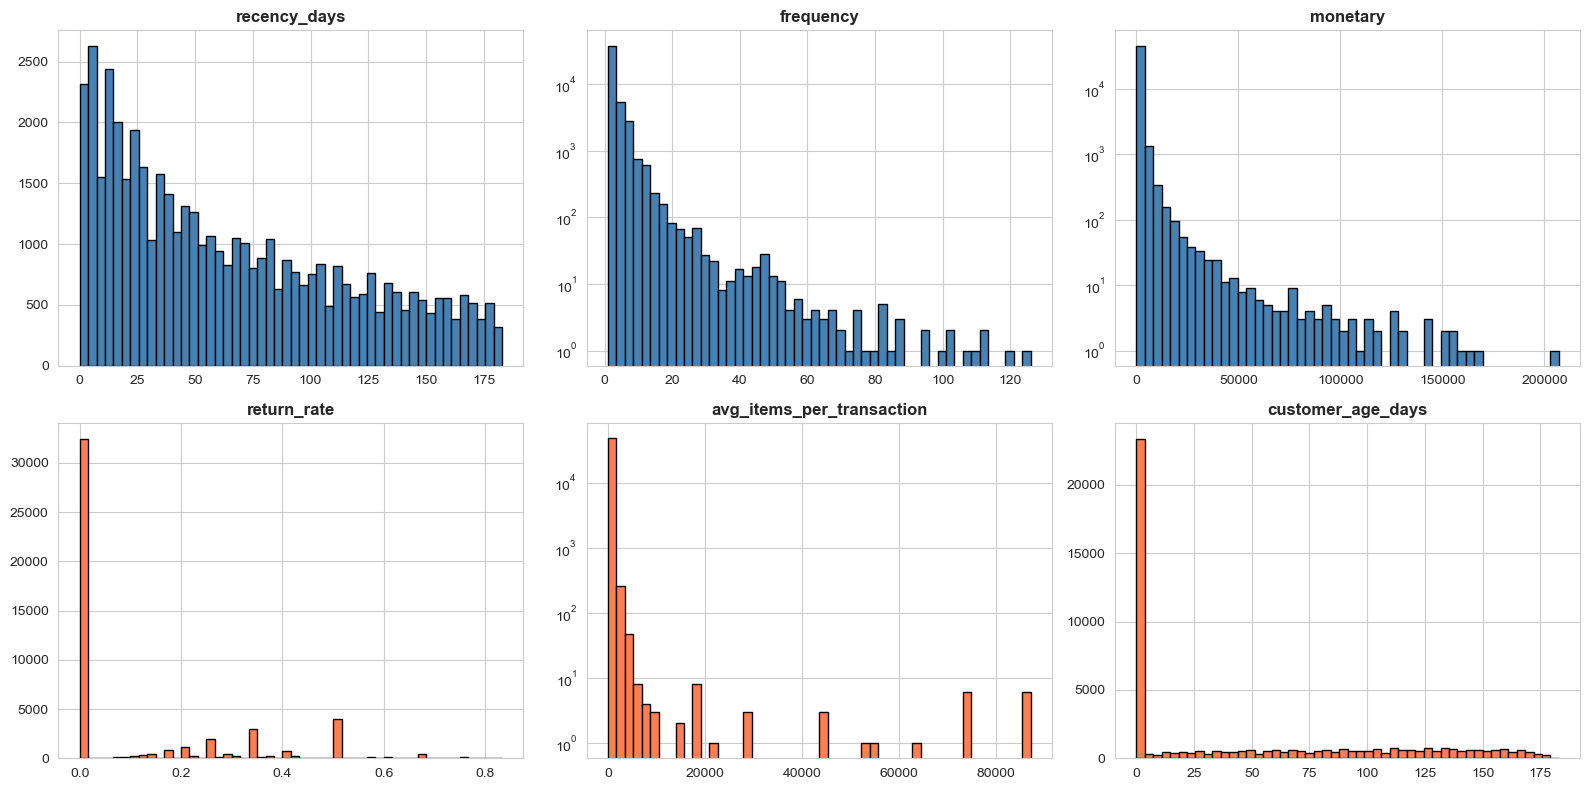

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col, color in zip(
    axes.ravel(),
    ['recency_days', 'frequency', 'monetary',
     'return_rate', 'avg_items_per_transaction', 'customer_age_days'],
    ['steelblue'] * 3 + ['coral'] * 3,
):
    feature_set[col].hist(ax=ax, bins=50, color=color, edgecolor='black')
    ax.set_title(col, fontweight='bold')
    if col in ('monetary', 'frequency', 'avg_items_per_transaction'):
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Relación de las features con el target

Comprobación de sanidad: las features deben separar churners de no-churners sin ser
deterministas sobre el target.

**El RFM clásico no se ordena aquí como sugiere el manual.** La *R* —`recency_days`— es la
variable que la literatura de retención pone en primer lugar, y aquí queda **quinta de siete**
por AUC univariante, y cuarta por SHAP en la Fase 4.

Tres de las cuatro medidas disponibles coinciden en dejarla fuera del podio —AUC univariante,
coeficiente logístico y SHAP—. La cuarta no, y conviene decirlo en lugar de citar sólo las que
convienen: por **correlación simple queda segunda**, como muestra la tabla de arriba. La
discrepancia tiene explicación y es útil — la correlación en bruto castiga a `monetary` y
`frequency`, cuyas colas pesadas la hunden, y no a la recencia, que está acotada por la ventana;
medida sobre las variables ya transformadas con `log1p` —el espacio que ve el modelo— la
recencia vuelve al quinto puesto.

No es una anomalía: es consecuencia del diseño temporal. Dentro de una ventana de 6 meses la
recencia está acotada a ~183 días y el horizonte que se predice son 90. Un cliente que lleva 40
días sin comprar y otro que lleva 70 se distinguen poco de cara al trimestre siguiente, mientras
que haber comprado una vez o siete en el semestre separa mucho. Dicho en términos de negocio:
**la *R* dice cuándo intervenir, la *F* dice en quién** — y por eso la Fase 4 usa la recencia
para definir la ventana de intervención y no para elegir al cliente.

Ninguna variable domina el target: todas dejan amplio solape entre clases, que es exactamente
lo que el modelo debe resolver.

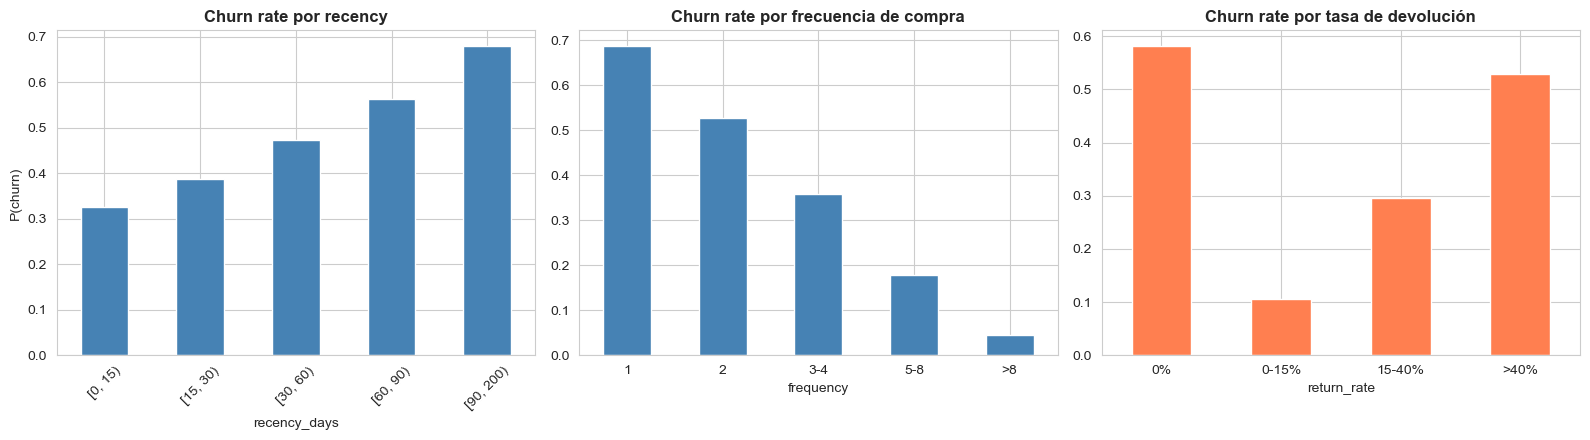

Correlación simple return_rate ~ churn: -0.098 (marginal, no condicional)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bins = pd.cut(feature_set['recency_days'], [0, 15, 30, 60, 90, 200], right=False)
feature_set.groupby(bins, observed=False)['churn'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Churn rate por recency', fontweight='bold')
axes[0].set_ylabel('P(churn)')
axes[0].tick_params(axis='x', rotation=45)

fbins = pd.cut(feature_set['frequency'], [0, 1, 2, 4, 8, 1000], right=True,
               labels=['1', '2', '3-4', '5-8', '>8'])
feature_set.groupby(fbins, observed=False)['churn'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Churn rate por frecuencia de compra', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

rbins = pd.cut(feature_set['return_rate'], [0, 0.001, 0.15, 0.4, 1.01], right=False,
               labels=['0%', '0-15%', '15-40%', '>40%'])
feature_set.groupby(rbins, observed=False)['churn'].mean().plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Churn rate por tasa de devolución', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# La hipótesis de partida del TFM era que devolver anticipa abandono. No se sostiene:
# la correlación simple es NEGATIVA y el coeficiente condicional de la Fase 4 también
# (-0,057). Devolver exige haber comprado, recibido el pedido y gestionado un retorno:
# es señal de actividad, no de desafección. Se documenta aquí para que las dos fases
# digan lo mismo; la lectura completa está en la Fase 4.
print(f"Correlación simple return_rate ~ churn: "
      f"{feature_set['return_rate'].corr(feature_set['churn']):+.3f} (marginal, no condicional)")

## Guardar

In [10]:
feature_set.to_csv('../outputs/fase2_features/customer_features_fase2.csv', index=False)

pd.DataFrame([
    ('recency_days', 'feature', 'Días entre la última compra y t'),
    ('frequency', 'feature', 'Facturas de COMPRA distintas en la ventana (excluye cancelaciones)'),
    ('monetary', 'feature', 'Gasto en la ventana histórica (£, solo líneas de compra)'),
    ('return_rate', 'feature', 'Facturas con devolución / facturas totales del cliente (0-1)'),
    ('customer_age_days', 'feature', 'Días entre primera y última compra DENTRO de la ventana'),
    ('avg_items_per_transaction', 'feature', 'Unidades compradas medias por factura de compra'),
    ('unique_products', 'feature', 'StockCodes distintos comprados'),
    ('avg_order_value', 'descriptiva',
     'monetary / frequency (£). Excluida del modelo: redundancia algebraica exacta '
     'con monetary y frequency (su VIF medido es 1,2: el motivo es conceptual, no de colinealidad)'),
    ('churn', 'TARGET', 'Sin ninguna COMPRA en [t, t+90d). Equivale a future_monetary_90d == 0'),
    ('future_monetary_90d', 'TARGET', 'Gasto en [t, t+90d) (£); 0 si no vuelve'),
], columns=['Feature', 'Rol', 'Definición']).to_csv('../outputs/fase2_features/feature_documentation.csv', index=False)

print("../outputs/fase2_features/customer_features_fase2.csv")
print("../outputs/fase2_features/feature_documentation.csv")

../outputs/fase2_features/customer_features_fase2.csv
../outputs/fase2_features/feature_documentation.csv
